In [ ]:
# https://hackmd.io/@s02260441/HJcMcnds8

In [ ]:
!pip install twstock

In [ ]:
import twstock
import pandas as pd

In [ ]:
# target_stock = '2633'  # 股票代號變數
# stock = twstock.Stock(target_stock) # 告訴twstock我們要查詢的股票
# target_price = stock.fetch_from(2020, 5) # 取用2020/05至今每天的交易資料
def stock(ID, date_year, date_month):
  global target_stock, stock, target_price, name_attribute
  target_stock = str(ID)  # 股票代號變數
  stock = twstock.Stock(target_stock) # 告訴twstock我們要查詢的股票
  target_price = stock.fetch_from(date_year, date_month) # 取用2020/05至今每天的交易資料
  name_attribute = ['Date', 'Capacity', 'Turnover', 'Open', 'High', 'Low', 'Close', 'Change', 'Transcation']
  df = pd.DataFrame(columns = name_attribute, data = target_price)
  return df

In [ ]:

# 幫收到的資料設表頭'日期', '成交量', '成交量', '開盤價', '最高價', '最低價', '收盤價', '變動',‘交易’
# name_attribute = ['Date', 'Capacity', 'Turnover', 'Open', 'High', 'Low', 'Close', 'Change', 'Transcation']
# df = pd.DataFrame(columns = name_attribute, data = target_price)
# display(df)
df = stock(ID=2633, date_year=2020, date_month=5)
display(df)

,Date,Capacity,Turnover,Open,High,Low,Close,Change,Transcation
0,2020-05-04,6010634,200409259,33.00,33.70,32.85,33.45,-0.65,3471
1,2020-05-05,3640535,121775515,33.50,33.65,33.30,33.35,-0.10,2053
2,2020-05-06,2882157,96167099,33.45,33.50,33.00,33.40,0.05,1371
3,2020-05-07,3465367,115690873,33.40,33.60,33.25,33.45,0.05,1797
4,2020-05-08,3563251,119449154,33.60,33.75,33.40,33.50,0.05,2040
...,...,...,...,...,...,...,...,...,...
968,2024-04-23,3491723,104400544,29.95,30.10,29.75,29.75,-0.20,1917
969,2024-04-24,2397160,71610999,29.95,30.00,29.80,29.85,0.10,1102
970,2024-04-25,2566314,76418711,29.90,29.90,29.70,29.75,-0.10,1146
971,2024-04-26,2635223,78544550,29.75,29.95,29.65,29.95,0.20,1115


畫圖

In [ ]:
!pip install mplfinance

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import mplfinance as mpf

In [ ]:
df.rename(columns={'Turnover':'Volume'}, inplace = True)  #這裡針對資料表做一下修正，因為交易量(Turnover)在mplfinance中須被改為Volume才能被認出來

In [ ]:
mc = mpf.make_marketcolors(up='r', down='g', inherit=True)  # 針對線圖的外觀微調，將上漲設定為紅色，下跌設定為綠色，符合台股表示習慣
s  = mpf.make_mpf_style(base_mpf_style='yahoo', marketcolors=mc)  # 接著把自訂的marketcolors放到自訂的style中，而這個改動是基於預設的yahoo外觀

In [ ]:
# 設定可變參數kwargs，並在變數中填上繪圖時會用到的設定值
kwargs = dict(type='candle', mav=(5, 20, 60), volume=True, figratio=(10,8), figscale=0.75, title=target_stock, style=s)

/usr/local/lib/python3.10/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


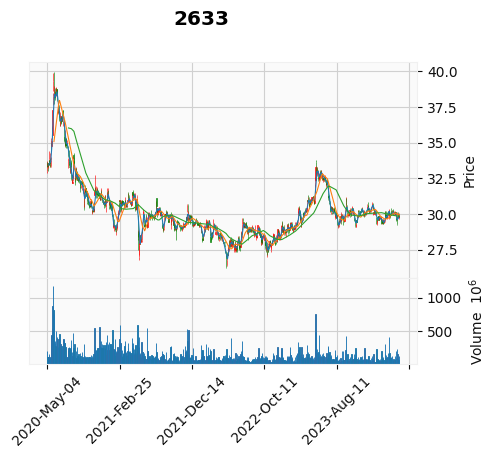

In [ ]:
df.set_index('Date', inplace=True)  # 調整時間格式
mpf.plot(df, **kwargs) # 選擇df資料表為資料來源，帶入kwargs參數，畫出目標股票的走勢圖

In [ ]:
x = target_price
# for i in x:
#   print(i.change)

In [ ]:
# 取出 x[0] 中所有的 keys
keys = x[0]._fields

# 打印 keys
print(keys)

('date', 'capacity', 'turnover', 'open', 'high', 'low', 'close', 'change', 'transaction')


In [ ]:
import twstock.realtime

# real time
twstock.realtime.mock = False  # 使用正常資料
real_data = twstock.realtime.get('2633')            # 單一查詢
# twstock.realtime.get(['2330', '6223'])  # 多重查詢

real_data_df = pd.DataFrame(real_data)
display(real_data_df)

,timestamp,info,realtime,success
code,1.714372e+09,2633,NaN,True
channel,1.714372e+09,2633.tw,NaN,True
name,1.714372e+09,台灣高鐵,NaN,True
fullname,1.714372e+09,台灣高速鐵路股份有限公司,NaN,True
time,1.714372e+09,2024-04-29 06:30:00,NaN,True
latest_trade_price,1.714372e+09,NaN,30.0500,True
trade_volume,1.714372e+09,NaN,652,True
accumulate_trade_volume,1.714372e+09,NaN,4198,True
best_bid_price,1.714372e+09,NaN,"[30.0000, 29.9500, 29.9000, 29.8500, 29.8000]",True
best_bid_volume,1.714372e+09,NaN,"[340, 418, 462, 195, 280]",True


In [ ]:
df

,Capacity,Volume,Open,High,Low,Close,Change,Transcation
Date,,,,,,,,
2020-05-04,6010634,200409259,33.00,33.70,32.85,33.45,-0.65,3471
2020-05-05,3640535,121775515,33.50,33.65,33.30,33.35,-0.10,2053
2020-05-06,2882157,96167099,33.45,33.50,33.00,33.40,0.05,1371
2020-05-07,3465367,115690873,33.40,33.60,33.25,33.45,0.05,1797
2020-05-08,3563251,119449154,33.60,33.75,33.40,33.50,0.05,2040
...,...,...,...,...,...,...,...,...
2024-04-23,3491723,104400544,29.95,30.10,29.75,29.75,-0.20,1917
2024-04-24,2397160,71610999,29.95,30.00,29.80,29.85,0.10,1102
2024-04-25,2566314,76418711,29.90,29.90,29.70,29.75,-0.10,1146


In [ ]:
# x = [成交量, 成交金額, 開盤金額, 最高金額, 最低金額, 收盤金額, 當天漲跌幅, 成交筆數]
# y = [隔天漲跌幅]
# for i in x:
#   print(i)
data = []
target = []

i=4
for i in range(3, len(x)-1, 1):
  data.append([x[i-3].capacity, x[i-3].turnover, x[i-3].open, x[i-3].high, x[i-3].low, x[i-3].close, x[i-3].change, x[i-3].transaction, \
        x[i-2].capacity, x[i-2].turnover, x[i-2].open, x[i-2].high, x[i-2].low, x[i-2].close, x[i-2].change, x[i-2].transaction, \
        x[i-1].capacity, x[i-1].turnover, x[i-1].open, x[i-1].high, x[i-1].low, x[i-1].close, x[i-1].change, x[i-1].transaction, \
        x[i].capacity, x[i].turnover, x[i].open, x[i].high, x[i].low, x[i].close, x[i].change, x[i].transaction])
  target.append(x[i+1].change)

x[4]

Data(date=datetime.datetime(2020, 5, 8, 0, 0), capacity=3563251, turnover=119449154, open=33.6, high=33.75, low=33.4, close=33.5, change=0.05, transaction=2040)

In [ ]:
print('len(data): ', len(data))
print('len(target):', len(target))

len(data):  969
len(target): 969


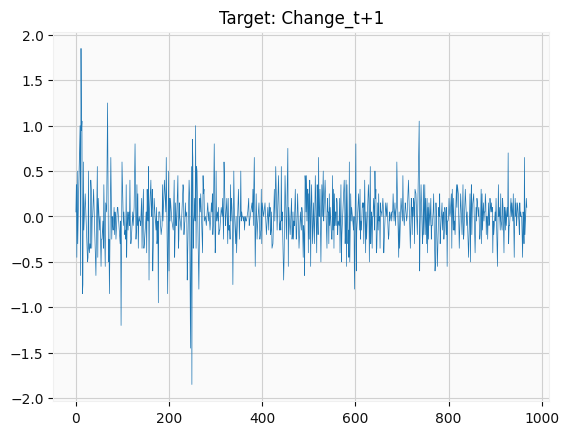

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["font.family"] = "DejaVu Sans"
# plt.figure(facecolor='#F2F2F2', figsize=(22,6))
plt.title('Target: Change_t+1')
plt.plot(target, lw=0.5)
# plt.xlim(0, 1000)

In [ ]:
def normalize_data(data):
    """
    將數據規一化到 [0, 1] 範圍內，並四捨五入到小數點後五位。

    Args:
        data (array-like): 要規一化的數據，可以是列表、NumPy 數組等。

    Returns:
        array-like: 規一化後且四捨五入到小數點後五位的數據。
    """
    # 找到每個維度的最小值和最大值
    min_vals = [min(dim) for dim in zip(*data)]
    max_vals = [max(dim) for dim in zip(*data)]

    # 規一化數據並四捨五入到小數點後五位
    normalized_data = []
    for item in data:
        normalized_item = [(x - min_val) / (max_val - min_val) for x, min_val, max_val in zip(item, min_vals, max_vals)]
        normalized_item = [round(val, 5) for val in normalized_item]
        normalized_data.append(normalized_item)

    return normalized_data

norm_data = normalize_data(data)

for i in range(len(target)):
  if target[i]>0:
    target[i]=1
  else:
    target[i]=0

In [ ]:
print('data: ', data)
print('norm_data: ', norm_data)
print('target: ', target)
print('data.shape: ', np.array(data).shape)
print('norm_data.shape: ', np.array(norm_data).shape)

data:  [[6010634, 200409259, 33.0, 33.7, 32.85, 33.45, -0.65, 3471, 3640535, 121775515, 33.5, 33.65, 33.3, 33.35, -0.1, 2053, 2882157, 96167099, 33.45, 33.5, 33.0, 33.4, 0.05, 1371, 3465367, 115690873, 33.4, 33.6, 33.25, 33.45, 0.05, 1797], [3640535, 121775515, 33.5, 33.65, 33.3, 33.35, -0.1, 2053, 2882157, 96167099, 33.45, 33.5, 33.0, 33.4, 0.05, 1371, 3465367, 115690873, 33.4, 33.6, 33.25, 33.45, 0.05, 1797, 3563251, 119449154, 33.6, 33.75, 33.4, 33.5, 0.05, 2040], [2882157, 96167099, 33.45, 33.5, 33.0, 33.4, 0.05, 1371, 3465367, 115690873, 33.4, 33.6, 33.25, 33.45, 0.05, 1797, 3563251, 119449154, 33.6, 33.75, 33.4, 33.5, 0.05, 2040, 4799015, 162866988, 33.6, 34.4, 33.55, 33.85, 0.35, 2442], [3465367, 115690873, 33.4, 33.6, 33.25, 33.45, 0.05, 1797, 3563251, 119449154, 33.6, 33.75, 33.4, 33.5, 0.05, 2040, 4799015, 162866988, 33.6, 34.4, 33.55, 33.85, 0.35, 2442, 3722701, 124688481, 33.55, 33.75, 33.4, 33.4, -0.45, 2105], [3563251, 119449154, 33.6, 33.75, 33.4, 33.5, 0.05, 2040, 47990

In [ ]:
import torch
from sklearn.model_selection import train_test_split

x = norm_data
y = target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

torch_data = torch.tensor(x_train).to(torch.float).cuda()
torch_target= torch.tensor(y_train).to(torch.long).cuda()
test_torch_data = torch.tensor(x_test).to(torch.float).cuda()
test_torch_target= torch.tensor(y_test).to(torch.long).cuda()

print(torch_target[0])

tensor(1, device='cuda:0')
